Libraries imported successfully!

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset Shape:
(150, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing Val

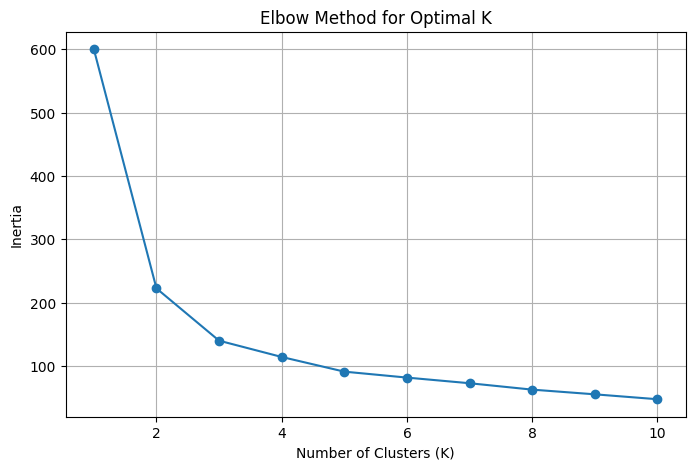


Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

Cluster Centers (Scaled):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

Cluster Centers (Original Scale):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.801887          2.673585           4.369811          1.413208
1           5.006000          3.428000           1.462000          0.246000
2           6.780851          3.095745           5.510638          1.972340

Dataset with Cluster Labels:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5          

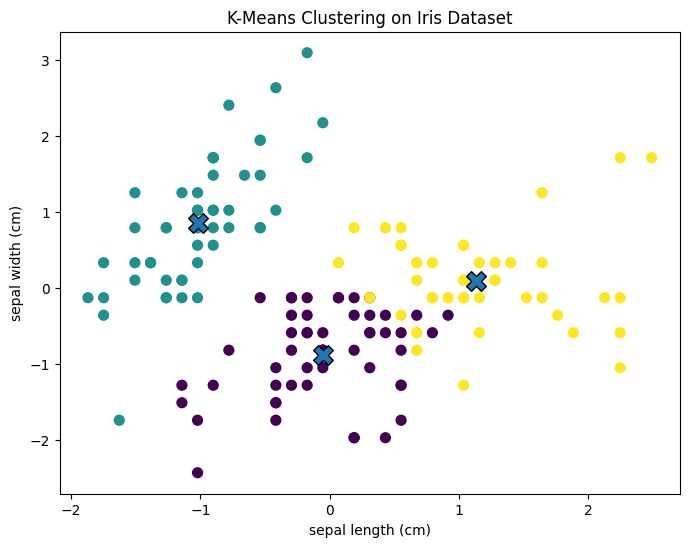


PCA Data:
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Explained Variance: 0.9581320720000166


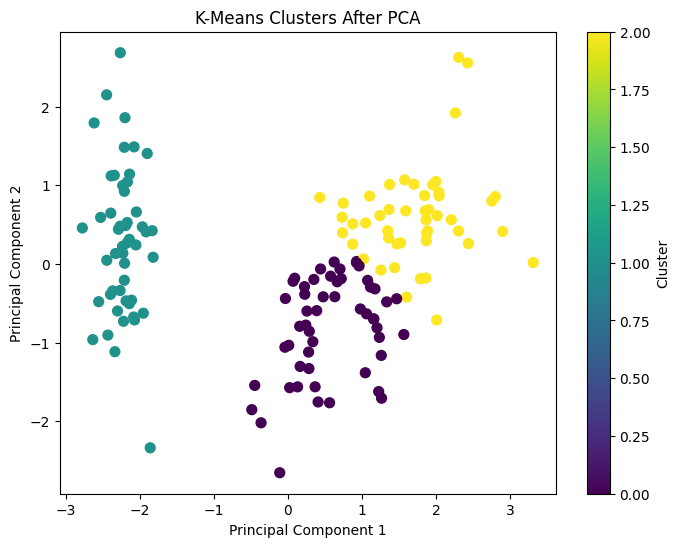

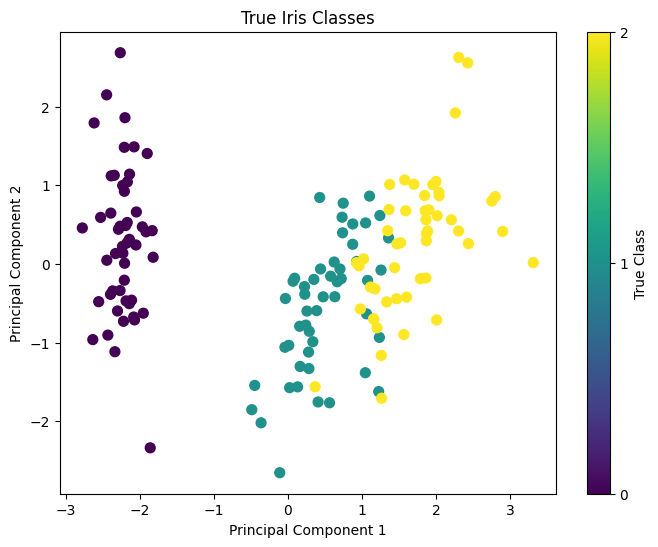


First 20 Comparisons:
    True_Label  Predicted_Cluster
0            0                  1
1            0                  1
2            0                  1
3            0                  1
4            0                  1
5            0                  1
6            0                  1
7            0                  1
8            0                  1
9            0                  1
10           0                  1
11           0                  1
12           0                  1
13           0                  1
14           0                  1
15           0                  1
16           0                  1
17           0                  1
18           0                  1
19           0                  1

Adjusted Rand Index:
0.6201351808870379


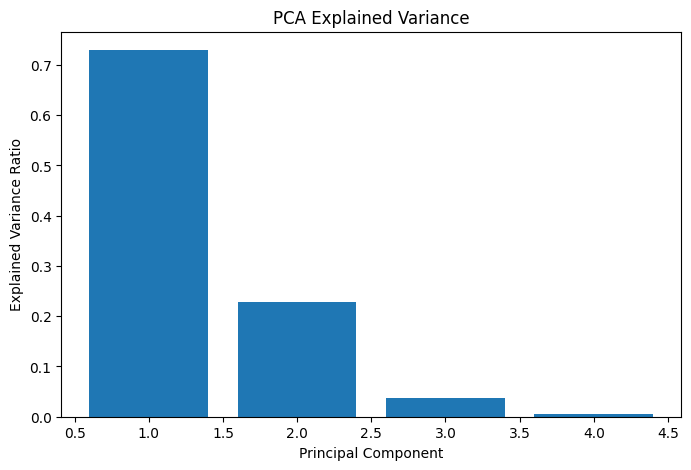


PCA DataFrame:
        PC1       PC2  Cluster  True_Label
0 -2.264703  0.480027        1           0
1 -2.080961 -0.674134        1           0
2 -2.364229 -0.341908        1           0
3 -2.299384 -0.597395        1           0
4 -2.389842  0.646835        1           0

iris_clustered.csv saved successfully!
iris_pca.csv saved successfully!
K-Means model saved using Joblib.
K-Means model saved using Pickle.
Scaler saved successfully.
PCA model saved successfully.

K-Means model loaded successfully!

Predictions from Loaded Model:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

WEEK 3 PROJECT COMPLETED
Dataset: Iris
Algorithm: K-Means Clustering
Number of Clusters: 3
PCA Components: 2
Adjusted Rand Index: 0.6201351808870379

Files Created:
1. iris_clustered.csv
2. iris_pca.csv
3. kmeans_iris.joblib
4. kmeans_iris.pkl
5. iris_scaler.joblib
6. iris_pca_model.joblib

All tasks completed successfully!


In [2]:
# ============================================================
# WEEK 3 - UNSUPERVISED LEARNING AND MODEL EVALUATION
# K-Means Clustering + PCA + Model Saving/Loading
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

print("Libraries imported successfully!")


# -----------------------------
# 2. LOAD IRIS DATASET
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# -----------------------------
# 3. BASIC STATISTICS
# -----------------------------
print("\nStatistical Summary:")
print(df.describe())


# -----------------------------
# 4. STANDARDIZE THE DATA
# -----------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data:")
print(X_scaled[:5])


# -----------------------------
# 5. ELBOW METHOD
# -----------------------------
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    # Correct property: inertia_
    inertia.append(kmeans.inertia_)


# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.show()


# -----------------------------
# 6. K-MEANS CLUSTERING
# -----------------------------
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("\nCluster Labels:")
print(clusters)


# -----------------------------
# 7. CLUSTER CENTERS
# -----------------------------
print("\nCluster Centers (Scaled):")
print(kmeans.cluster_centers_)


# Convert centers back to original scale
cluster_centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print("\nCluster Centers (Original Scale):")

centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=feature_names
)

print(centers_df)


# -----------------------------
# 8. ADD CLUSTER LABELS
# -----------------------------
df["Cluster"] = clusters

print("\nDataset with Cluster Labels:")
print(df.head())


# -----------------------------
# 9. CLUSTER COUNTS
# -----------------------------
print("\nNumber of Samples in Each Cluster:")

print(
    df["Cluster"].value_counts().sort_index()
)


# -----------------------------
# 10. VISUALIZE K-MEANS CLUSTERS
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])

plt.title("K-Means Clustering on Iris Dataset")

plt.show()


# -----------------------------
# 11. PCA - REDUCE TO 2 DIMENSIONS
# -----------------------------
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Data:")
print(X_pca[:5])


# -----------------------------
# 12. EXPLAINED VARIANCE
# -----------------------------
print("\nExplained Variance Ratio:")

print(pca.explained_variance_ratio_)

print(
    "\nTotal Explained Variance:",
    sum(pca.explained_variance_ratio_)
)


# -----------------------------
# 13. PCA CLUSTER VISUALIZATION
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters After PCA")

plt.colorbar(label="Cluster")

plt.show()


# -----------------------------
# 14. TRUE IRIS LABEL VISUALIZATION
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("True Iris Classes")

plt.colorbar(
    ticks=[0, 1, 2],
    label="True Class"
)

plt.show()


# -----------------------------
# 15. COMPARE CLUSTERS WITH TRUE LABELS
# -----------------------------
comparison_df = pd.DataFrame({
    "True_Label": y,
    "Predicted_Cluster": clusters
})

print("\nFirst 20 Comparisons:")
print(comparison_df.head(20))


# -----------------------------
# 16. ADJUSTED RAND INDEX
# -----------------------------
ari = adjusted_rand_score(y, clusters)

print("\nAdjusted Rand Index:")
print(ari)


# -----------------------------
# 17. PCA EXPLAINED VARIANCE GRAPH
# -----------------------------
pca_full = PCA()

pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("PCA Explained Variance")

plt.show()


# -----------------------------
# 18. CREATE PCA DATAFRAME
# -----------------------------
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters
pca_df["True_Label"] = y

print("\nPCA DataFrame:")
print(pca_df.head())


# -----------------------------
# 19. SAVE CLUSTERED DATASET
# -----------------------------
df.to_csv(
    "iris_clustered.csv",
    index=False
)

print("\niris_clustered.csv saved successfully!")


# -----------------------------
# 20. SAVE PCA DATASET
# -----------------------------
pca_df.to_csv(
    "iris_pca.csv",
    index=False
)

print("iris_pca.csv saved successfully!")


# -----------------------------
# 21. SAVE K-MEANS MODEL USING JOBLIB
# -----------------------------
joblib.dump(
    kmeans,
    "kmeans_iris.joblib"
)

print("K-Means model saved using Joblib.")


# -----------------------------
# 22. SAVE K-MEANS MODEL USING PICKLE
# -----------------------------
with open(
    "kmeans_iris.pkl",
    "wb"
) as file:

    pickle.dump(
        kmeans,
        file
    )

print("K-Means model saved using Pickle.")


# -----------------------------
# 23. SAVE SCALER
# -----------------------------
joblib.dump(
    scaler,
    "iris_scaler.joblib"
)

print("Scaler saved successfully.")


# -----------------------------
# 24. SAVE PCA MODEL
# -----------------------------
joblib.dump(
    pca,
    "iris_pca_model.joblib"
)

print("PCA model saved successfully.")


# -----------------------------
# 25. LOAD K-MEANS MODEL
# -----------------------------
loaded_kmeans = joblib.load(
    "kmeans_iris.joblib"
)

print("\nK-Means model loaded successfully!")


# -----------------------------
# 26. TEST LOADED MODEL
# -----------------------------
new_predictions = loaded_kmeans.predict(
    X_scaled
)

print("\nPredictions from Loaded Model:")
print(new_predictions[:20])


# -----------------------------
# 27. FINAL RESULTS
# -----------------------------
print("\n===================================")
print("WEEK 3 PROJECT COMPLETED")
print("===================================")

print("Dataset: Iris")
print("Algorithm: K-Means Clustering")
print("Number of Clusters: 3")
print("PCA Components: 2")
print("Adjusted Rand Index:", ari)

print("\nFiles Created:")
print("1. iris_clustered.csv")
print("2. iris_pca.csv")
print("3. kmeans_iris.joblib")
print("4. kmeans_iris.pkl")
print("5. iris_scaler.joblib")
print("6. iris_pca_model.joblib")

print("\nAll tasks completed successfully!")